### Imports and setup


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib 


print("Loading imputed training and testing data...")
# We use the IMPUTED data here because Random Forest cannot handle NaNs
X_train = pd.read_csv('../data/X_train_clean_imputed.csv')
X_test = pd.read_csv('../data/X_test_clean_imputed.csv')

# .values.ravel() flattens the pandas column into a 1D array, which sklearn prefers for 'y'
y_train = pd.read_csv('../data/y_train_clean.csv').values.ravel() 
y_test = pd.read_csv('../data/y_test_clean.csv').values.ravel()

# Save feature names for the importance chart later
feature_names = X_train.columns.tolist()

# Define the clinic names 
clinic_names = ['Aimolipsies', 'Kardiologiki', 'Nefrologiki']

Loading imputed training and testing data...


### Train the Random Forest Model

In [10]:
print("Training Balanced Random Forest...")

# We use class_weight='balanced' to ensure Nefrologiki gets fair representation
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores to train much faster
)

rf_clf.fit(X_train, y_train)

Training Balanced Random Forest...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### Evaluate the Model

In [11]:
y_pred_rf = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Accuracy: {accuracy:.2%}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=clinic_names))


Random Forest Accuracy: 66.67%
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

 Aimolipsies       0.71      0.75      0.73      1567
Kardiologiki       0.73      0.66      0.69      1567
 Nefrologiki       0.57      0.60      0.58      1568

    accuracy                           0.67      4702
   macro avg       0.67      0.67      0.67      4702
weighted avg       0.67      0.67      0.67      4702



### Visualize the Confusion Matrix

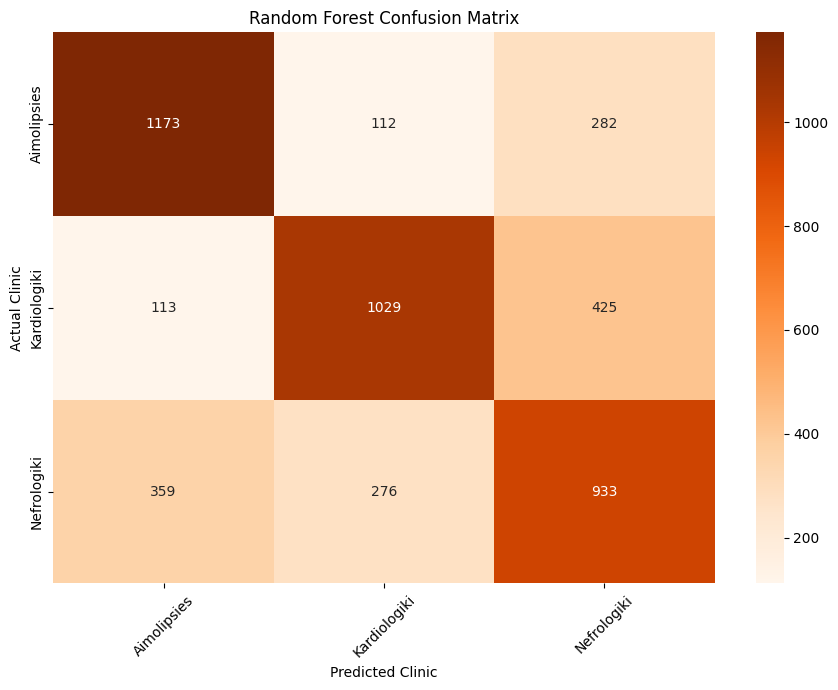

In [12]:
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=clinic_names, yticklabels=clinic_names)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Clinic')
plt.xlabel('Predicted Clinic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Native Feature Importance

Calculating Feature Importance...


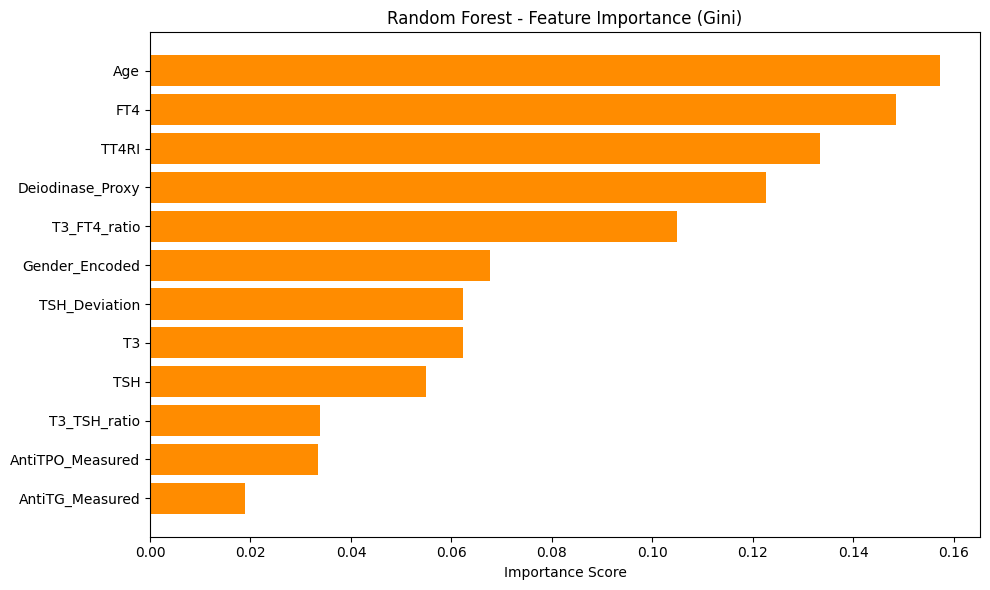

In [13]:
print("Calculating Feature Importance...")
importances = rf_clf.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='darkorange')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Random Forest - Feature Importance (Gini)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Save the Model for Final Comparison

In [14]:
import os
os.makedirs('models', exist_ok=True)

print("\nSaving model to 'models/random_forest_model.pkl'...")
joblib.dump(rf_clf, 'models/random_forest_model.pkl')
print("Model saved successfully!")


Saving model to 'models/random_forest_model.pkl'...
Model saved successfully!
